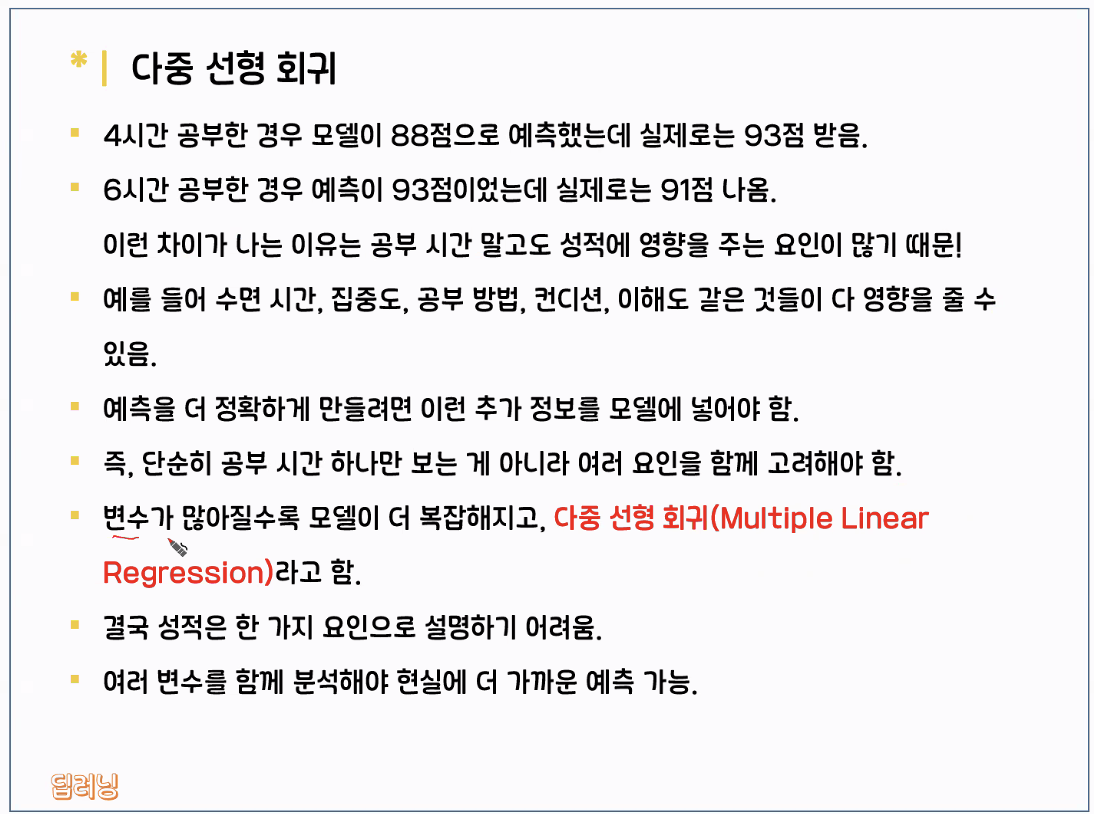

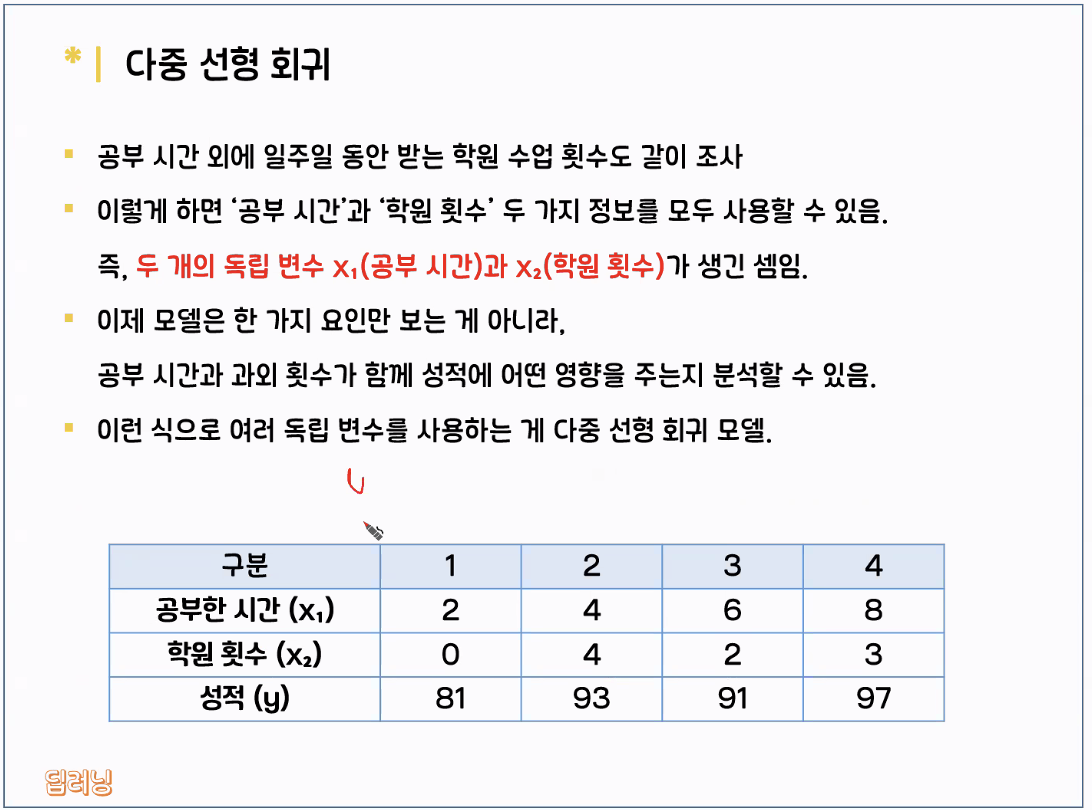

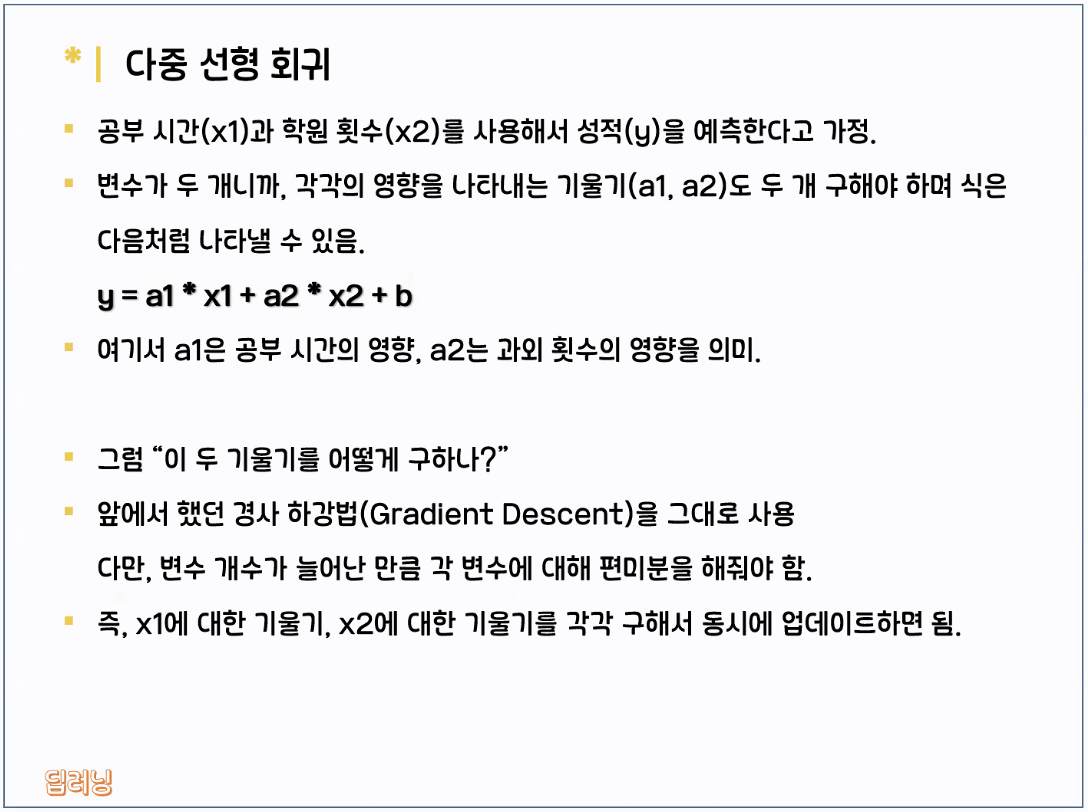

In [3]:
import tensorflow as tf

# x, y의 데이터 값
data = [[2, 0, 81], [4, 4, 93], [6, 2, 91], [8, 3, 97]]
x1 = [x_row1[0] for x_row1 in data]
x2 = [x_row2[1] for x_row2 in data]
y_data = [y_row[2] for y_row in data]

# 기울기 a와 y 절편 b의 값을 임의로 정한다.
# 단, 기울기의 범위는 0~10 사이이며, y 절편은 0~100사이에서 변하게 한다.
a1 = tf.Variable(tf.random.uniform([1], 0, 10, dtype = tf.float64, seed = 0))
a2 = tf.Variable(tf.random.uniform([1], 0, 10, dtype = tf.float64, seed = 0))
b = tf.Variable(tf.random.uniform([1], 0, 100, dtype = tf.float64, seed = 0))

# 기울기와 절편을 통해 계산되는 예상 Y 값
def hypothesis(a1, a2, b): # 가설
    return x1 * a1 + x2 * a2 + b
    
def cost(a1, a2, b): # 손실을 계산하는 함수
    return tf.sqrt(tf.reduce_mean(tf.square(hypothesis(a1, a2, b) - y_data )))

# 확률적 경사하강법
opt = tf.keras.optimizers.SGD(learning_rate=0.1)
for i in range(5000): #steps
    # 자동 미분을 위한 테이프
    with tf.GradientTape() as tape:
        loss = cost(a1, a2, b) # 기록할 내용이 w, b임을 명시
    gradients = tape.gradient(loss, [a1, a2, b]) # 손실에 대한 w, b의 미분값 계산
    opt.apply_gradients(zip(gradients, [a1, a2,b])) # 미분값으로 w와 b를 업데이트(조정)
    
    if i % 100 == 0:
        print(i, f'{loss.numpy()}, {a1.numpy()}, {a2.numpy()}, {b.numpy()}')

0 21.416865139696796, [4.96852536], [0.50657417], [81.05836373]
100 1.8365511787115216, [1.0864067], [2.11383881], [78.85141816]
200 1.8369294629394104, [1.16784211], [2.14190843], [78.24812732]
300 1.836992642003952, [1.20363454], [2.154153], [77.99497574]
400 1.8370036867476807, [1.21892749], [2.15941323], [77.88867155]
500 1.8370056327598945, [1.22539724], [2.16164355], [77.84402041]
600 1.8370059761073423, [1.22812317], [2.16258413], [77.82526359]
700 1.8370060367010526, [1.22926976], [2.16297991], [77.81738399]
800 1.8370060473950434, [1.22975169], [2.16314629], [77.81407377]
900 1.8370060492824003, [1.2299542], [2.16321621], [77.81268313]
1000 1.837006049615482, [1.23003928], [2.16324558], [77.81209892]
1100 1.8370060496742875, [1.23007503], [2.16325792], [77.81185349]
1200 1.8370060496846565, [1.23009004], [2.16326311], [77.81175038]
1300 1.837006049686505, [1.23009635], [2.16326529], [77.81170707]
1400 1.8370060496868204, [1.230099], [2.1632662], [77.81168887]
1500 1.8370060496

In [6]:
# 예측 3 시간 5 시간 공부했을 때 점수
new_x1 = tf.constant([3.0, 9.0], dtype=tf.float64) # 공부 시간
new_x2 = tf.constant([2.0, 5.0], dtype=tf.float64) # 학원 횟수

raw_scores = new_x1 * a1 + new_x2 * a2 + b
pred_scores = tf.clip_by_value(raw_scores, 0., 100.) #0~100 범위로 제한
for hrs, pred in zip(new_x1.numpy(), pred_scores.numpy()):
    print(f"{hrs:.0f}시간 공부 예상 점수 -> {pred:.2f}")
    

3시간 공부 예상 점수 -> 88.03
9시간 공부 예상 점수 -> 100.00


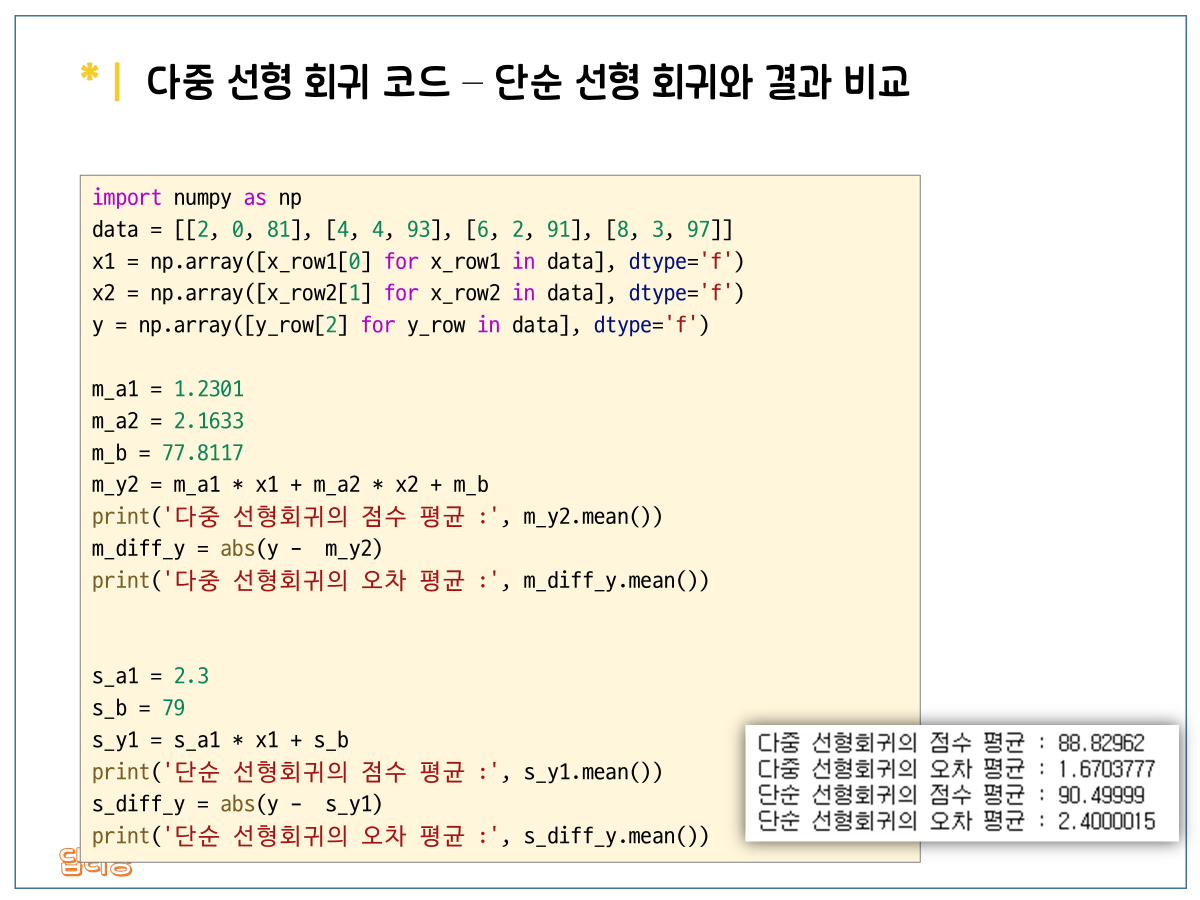

In [9]:
import numpy as np

data = np.loadtxt("Blood_fat.csv", delimiter = ",")

x1 = [x_row1[0] for x_row1 in data]
x2 = [x_row2[1] for x_row2 in data]
y = [y_row[2] for y_row in data]